In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
data = pd.read_csv('../data/ratings.csv')

print(data.head(),"\n")
print(data.info(),"\n")
print(data.describe())

         Date               Name  Year        Letterboxd URI  Rating
0  2020-10-15           Whiplash  2014  https://boxd.it/7bQA     5.0
1  2020-10-15         Your Name.  2016  https://boxd.it/cUqs     5.0
2  2020-10-15    The Dark Knight  2008  https://boxd.it/2b0k     5.0
3  2020-10-15      Black Panther  2018  https://boxd.it/8MHs     4.0
4  2020-10-15  Avengers: Endgame  2019  https://boxd.it/9vE4     4.5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1005 non-null   object 
 1   Name            1005 non-null   object 
 2   Year            1005 non-null   int64  
 3   Letterboxd URI  1005 non-null   object 
 4   Rating          1005 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 39.4+ KB
None 

              Year       Rating
count  1005.000000  1005.000000
mean   2013.407960     3.5447

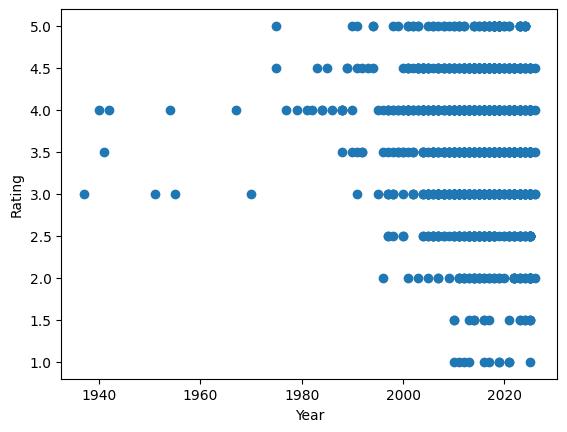

In [10]:
plt.scatter(data["Year"], data["Rating"])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

In [28]:
X = data["Year"].values.reshape(-1, 1)
y = data["Rating"]

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

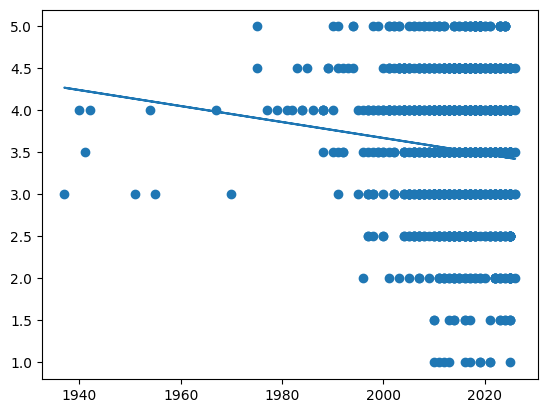

In [32]:
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.show()

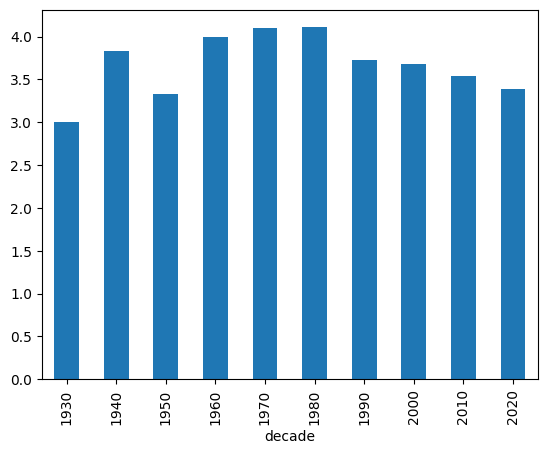

In [44]:
data["decade"] = (data["Year"] // 10) * 10
data.groupby("decade")["Rating"].mean().plot(kind="bar")

X = data["decade"].values.reshape(-1, 1)
y = data["Rating"]

In [47]:
new_model = LinearRegression()
new_model.fit(X, y)

LinearRegression()

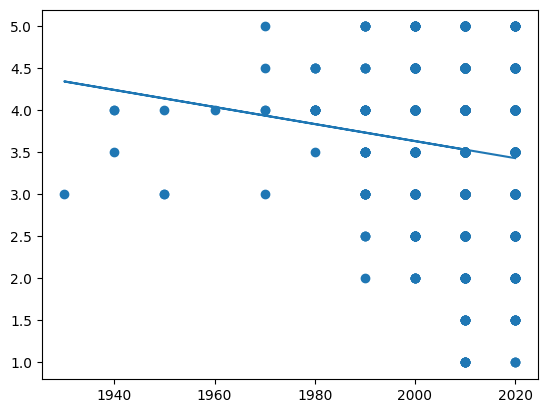

In [48]:
plt.scatter(X, y)
plt.plot(X, new_model.predict(X))
plt.show()

In [51]:
import requests

def get_genre(title, year):
    url = f"http://www.omdbapi.com/?i=tt3896198&apikey=f0bec87f&t={title}&y={year}"
    response = requests.get(url).json()
    return response.get("Genre", None)

In [52]:
data["Genre"] = data.apply(lambda row: get_genre(row["Name"], row["Year"]), axis=1)

In [53]:
data["Genre"] = data["Genre"].str.split(", ")

<Axes: xlabel='Genre'>

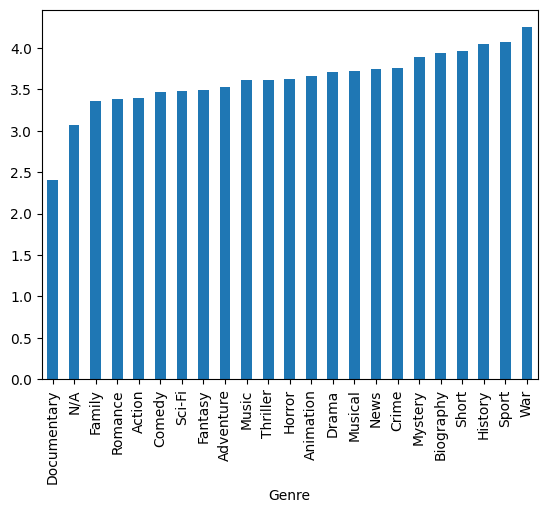

In [54]:
data_exploded = data.explode("Genre")

data_exploded.groupby("Genre")["Rating"].mean().sort_values().plot(kind="bar")